In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

data = pd.read_csv('../data/sp500_raw.csv', index_col=0, parse_dates=True)
data['log_return'] = np.log(data['Close'] / data['Close'].shift(1))
data = data.dropna()
data.head()

,Close,High,Low,Open,Volume,log_return
Date,,,,,,
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000,-0.018447
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000,-0.008933
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000,0.011563
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000,0.017730
2015-01-09,2044.810059,2064.429932,2038.329956,2063.449951,3364140000,-0.008439


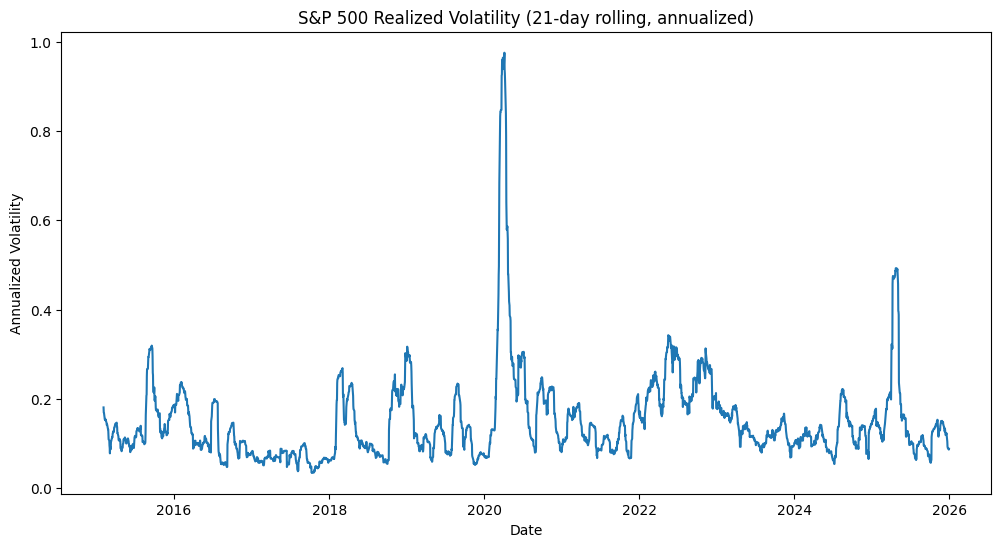

In [6]:
data['realized_volatility'] = data['log_return'].rolling(window=21).std() * np.sqrt(252)
data = data.dropna()

plt.figure(figsize=(12, 6))
plt.plot(data.index, data['realized_volatility'])
plt.title('S&P 500 Realized Volatility (21-day rolling, annualized)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.show()

In [7]:
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price